# Predictive Maintenance & Anomaly Detection
# MetroPT-3

**Goal:** Understand the dataset structure, sensor behavior, and known failure events before applying any anomaly detection methods.

**Dataset:** MetroPT-3 (UCI Machine Learning Repository) — real multivariate time-series sensor data (pressure, temperature, motor current, air intake valves) from a metro train's Air Production Unit, with documented failure events.

### 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Data

In [2]:
df = pd.read_csv('data_input/metropt_3_dataset/MetroPT3(AirCompressor).csv')  # Load your dataset here

In [3]:
df.columns

Index(['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure',
       'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric',
       'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level',
       'Caudal_impulses'],
      dtype='str')

In [4]:
# Failures Table

failure_data = [
    {'nr': '#1', 'start_time': '2020-04-18 00:00:00', 'end_time': '2020-04-18 23:59:00',
     'failure': 'Air Leak', 'severity': 'High stress', 'report': None},
    {'nr': '#2', 'start_time': '2020-05-29 23:30:00', 'end_time': '2020-05-30 06:00:00',
     'failure': 'Air Leak', 'severity': 'High stress', 'report': 'Maintenance on 30Apr at 12:00'},
    {'nr': '#3', 'start_time': '2020-06-05 10:00:00', 'end_time': '2020-06-07 14:30:00',
     'failure': 'Air Leak', 'severity': 'High stress', 'report': 'Maintenance on 8Jun at 16:00'},
    {'nr': '#4', 'start_time': '2020-07-15 14:30:00', 'end_time': '2020-07-15 19:00:00',
     'failure': 'Air Leak', 'severity': 'High stress', 'report': 'Maintenance on 16Jul at 00:00'},
]

df_failures = pd.DataFrame(failure_data)
df_failures['start_time'] = pd.to_datetime(df_failures['start_time'])
df_failures['end_time'] = pd.to_datetime(df_failures['end_time'])

df_failures

,nr,start_time,end_time,failure,severity,report
0,#1,2020-04-18 00:00:00,2020-04-18 23:59:00,Air Leak,High stress,NaN
1,#2,2020-05-29 23:30:00,2020-05-30 06:00:00,Air Leak,High stress,Maintenance on 30Apr at 12:00
2,#3,2020-06-05 10:00:00,2020-06-07 14:30:00,Air Leak,High stress,Maintenance on 8Jun at 16:00
3,#4,2020-07-15 14:30:00,2020-07-15 19:00:00,Air Leak,High stress,Maintenance on 16Jul at 00:00


In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [6]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [7]:
df = df.set_index('timestamp')

In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0,1.367826,3.250930,-0.032,-0.014,-0.012,-0.0100,10.676
TP3,1516948.0,8.984611,0.639095,0.730,8.492,8.960,9.4920,10.302
H1,1516948.0,7.568155,3.333200,-0.036,8.254,8.784,9.3740,10.288
DV_pressure,1516948.0,0.055956,0.382402,-0.032,-0.022,-0.020,-0.0180,9.844
Reservoirs,1516948.0,8.985233,0.638307,0.712,8.494,8.960,9.4920,10.300
Oil_temperature,1516948.0,62.644182,6.516261,15.400,57.775,62.700,67.2500,89.050
Motor_current,1516948.0,2.050171,2.302053,0.020,0.040,0.045,3.8075,9.295
COMP,1516948.0,0.836957,0.369405,0.000,1.000,1.000,1.0000,1.000
DV_eletric,1516948.0,0.160611,0.367172,0.000,0.000,0.000,0.0000,1.000
Towers,1516948.0,0.919848,0.271528,0.000,1.000,1.000,1.0000,1.000


### 3. Resample Data

In [9]:

df_resampled = df.resample('1min').mean()
df_resampled.head()

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012286,9.327429,9.311143,-0.022857,9.328000,53.521429,0.040357,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:01:00,-0.013000,9.260000,9.243333,-0.023333,9.259667,53.420833,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:02:00,-0.012667,9.198333,9.182000,-0.022333,9.199000,53.325000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:03:00,-0.012333,9.136667,9.120667,-0.022667,9.136667,53.200000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:04:00,-0.013000,9.075667,9.060000,-0.023000,9.075667,53.129167,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [10]:
df_resampled.dropna(inplace=True)

In [11]:
df_resampled.reset_index(inplace=True)

In [12]:
df_resampled.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012286,9.327429,9.311143,-0.022857,9.328000,53.521429,0.040357,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:01:00,-0.013000,9.260000,9.243333,-0.023333,9.259667,53.420833,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:02:00,-0.012667,9.198333,9.182000,-0.022333,9.199000,53.325000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:03:00,-0.012333,9.136667,9.120667,-0.022667,9.136667,53.200000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:04:00,-0.013000,9.075667,9.060000,-0.023000,9.075667,53.129167,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [13]:
df_resampled = df_resampled.set_index('timestamp', drop=False)

In [14]:
df_resampled.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 252720 entries, 2020-02-01 00:00:00 to 2020-09-01 03:59:00
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   timestamp        252720 non-null  datetime64[us]
 1   TP2              252720 non-null  float64       
 2   TP3              252720 non-null  float64       
 3   H1               252720 non-null  float64       
 4   DV_pressure      252720 non-null  float64       
 5   Reservoirs       252720 non-null  float64       
 6   Oil_temperature  252720 non-null  float64       
 7   Motor_current    252720 non-null  float64       
 8   COMP             252720 non-null  float64       
 9   DV_eletric       252720 non-null  float64       
 10  Towers           252720 non-null  float64       
 11  MPG              252720 non-null  float64       
 12  LPS              252720 non-null  float64       
 13  Pressure_switch  252720 non-null  float64       
 1

In [15]:
time_diffs = df_resampled['timestamp'].diff()

In [16]:
time_diffs

timestamp
2020-02-01 00:00:00               NaT
2020-02-01 00:01:00   0 days 00:01:00
2020-02-01 00:02:00   0 days 00:01:00
2020-02-01 00:03:00   0 days 00:01:00
2020-02-01 00:04:00   0 days 00:01:00
                            ...      
2020-09-01 03:55:00   0 days 00:01:00
2020-09-01 03:56:00   0 days 00:01:00
2020-09-01 03:57:00   0 days 00:01:00
2020-09-01 03:58:00   0 days 00:01:00
2020-09-01 03:59:00   0 days 00:01:00
Name: timestamp, Length: 252720, dtype: timedelta64[us]

In [17]:
time_diffs.describe()

count                    252719
mean     0 days 00:01:12.877543
std      0 days 00:12:48.646449
min             0 days 00:01:00
25%             0 days 00:01:00
50%             0 days 00:01:00
75%             0 days 00:01:00
max             2 days 00:02:00
Name: timestamp, dtype: object

In [18]:
# Do gaps overlap the failures? 
threshold = pd.Timedelta(hours=1)
gap_starts = df_resampled.index.to_series().shift(1)[time_diffs > threshold]
gap_ends = df_resampled.index.to_series()[time_diffs > threshold]
gap_sizes = time_diffs[time_diffs > threshold]

df_gaps = pd.DataFrame({'gap_start': gap_starts.values, 'gap_end': gap_ends.values, 'gap_size': gap_sizes.values})
df_gaps.sort_values('gap_start')

,gap_start,gap_end,gap_size
0,2020-02-01 19:40:00,2020-02-01 23:15:00,0 days 03:35:00
1,2020-02-01 23:20:00,2020-02-02 04:34:00,0 days 05:14:00
2,2020-02-05 01:07:00,2020-02-05 04:28:00,0 days 03:21:00
3,2020-02-06 02:07:00,2020-02-06 07:52:00,0 days 05:45:00
4,2020-02-06 19:16:00,2020-02-06 23:33:00,0 days 04:17:00
...,...,...,...
154,2020-08-29 01:08:00,2020-08-29 04:55:00,0 days 03:47:00
155,2020-08-30 00:41:00,2020-08-30 04:26:00,0 days 03:45:00
156,2020-08-31 00:30:00,2020-08-31 01:49:00,0 days 01:19:00
157,2020-08-31 20:15:00,2020-09-01 00:37:00,0 days 04:22:00


In [19]:
df_failures

,nr,start_time,end_time,failure,severity,report
0,#1,2020-04-18 00:00:00,2020-04-18 23:59:00,Air Leak,High stress,NaN
1,#2,2020-05-29 23:30:00,2020-05-30 06:00:00,Air Leak,High stress,Maintenance on 30Apr at 12:00
2,#3,2020-06-05 10:00:00,2020-06-07 14:30:00,Air Leak,High stress,Maintenance on 8Jun at 16:00
3,#4,2020-07-15 14:30:00,2020-07-15 19:00:00,Air Leak,High stress,Maintenance on 16Jul at 00:00


In [20]:
overlaps = []
for _, gap in df_gaps.iterrows():
    for _, fail in df_failures.iterrows():
        if gap['gap_start'] <= fail['end_time'] and fail['start_time'] <= gap['gap_end']:
            overlaps.append({
                'gap_start': gap['gap_start'],
                'gap_end': gap['gap_end'],
                'failure_nr': fail['nr'],
                'failure_start': fail['start_time'],
                'failure_end': fail['end_time']
            })

df_overlaps = pd.DataFrame(overlaps)
df_overlaps

,gap_start,gap_end,failure_nr,failure_start,failure_end
0,2020-06-06 15:55:00,2020-06-06 19:42:00,#3,2020-06-05 10:00:00,2020-06-07 14:30:00
1,2020-06-07 14:19:00,2020-06-08 11:48:00,#3,2020-06-05 10:00:00,2020-06-07 14:30:00


Gaps do not overlap with failures #1, #2, or #4, but two significant gaps (totaling ~25 hours) occur during and immediately after failure #3, coinciding closely with its reported maintenance timestamp.


The second gap is the more interesting one: it starts at 14:19 on Jun 7 - just 11 minutes before the failure's documented end time of 14:30 - and then continues for another 21.5 hours, well past when the failure was supposedly "over." And recall the maintenance report for this failure says maintenance happened "8Jun at 16:00" - that's only about 4 hours after this gap ends (11:48 on Jun 8). That timeline lines up suspiciously well: it suggests the sensors may have gone dark as part of the same event that led to the eventual repair, and the "end time" in the failure report might reflect when someone stopped actively logging the issue, not necessarily when the physical problem (or the outage) actually resolved.

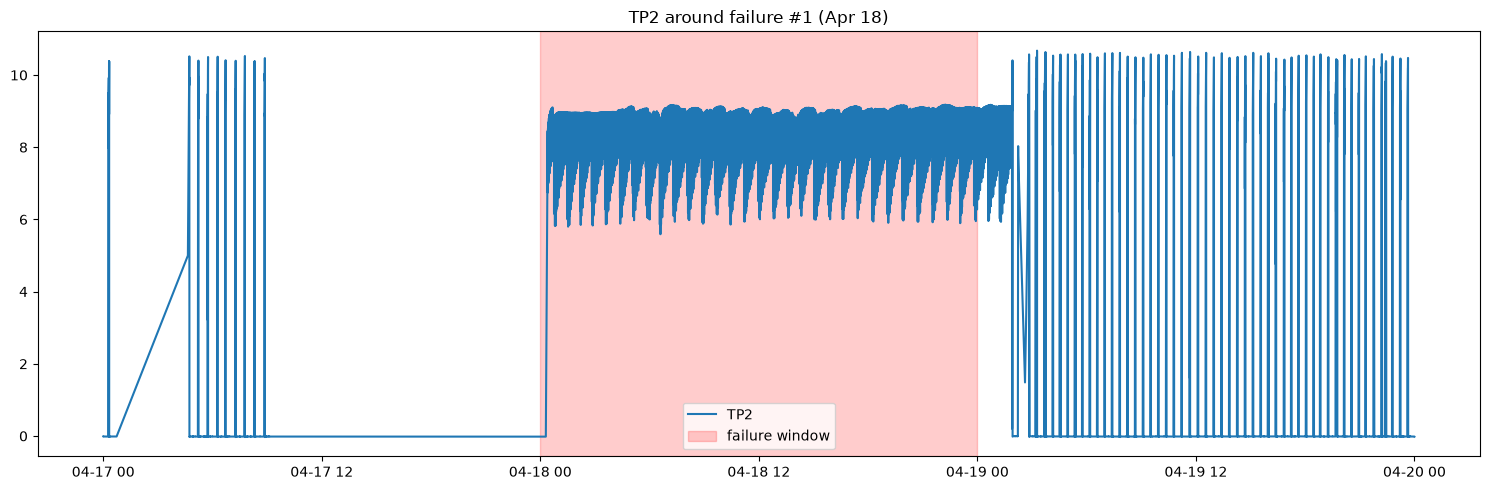

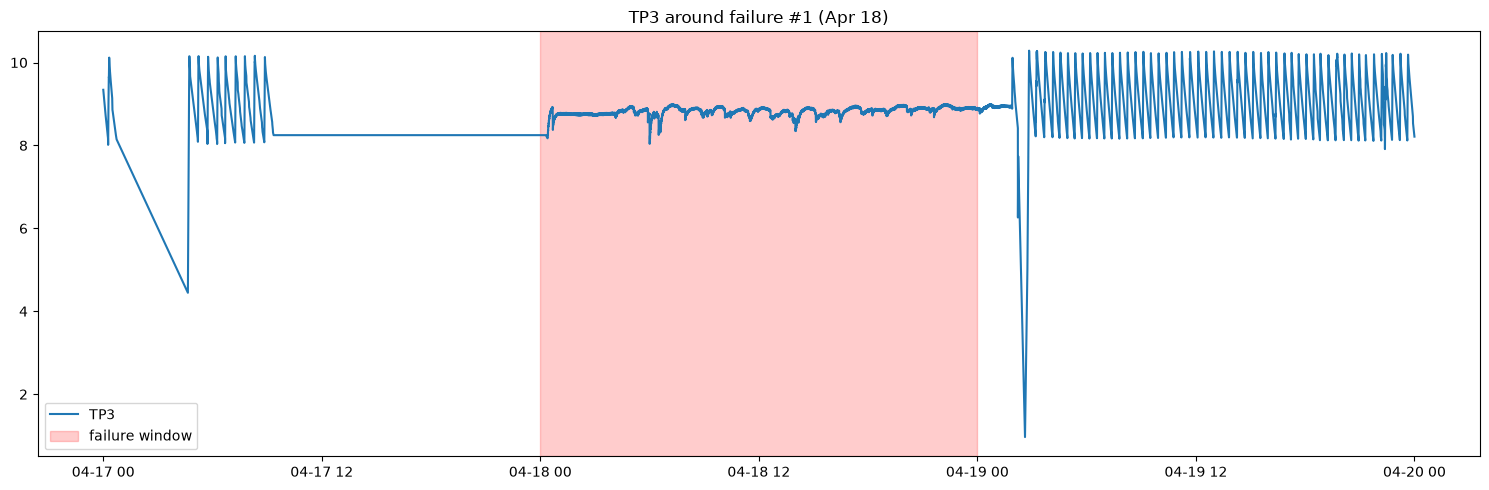

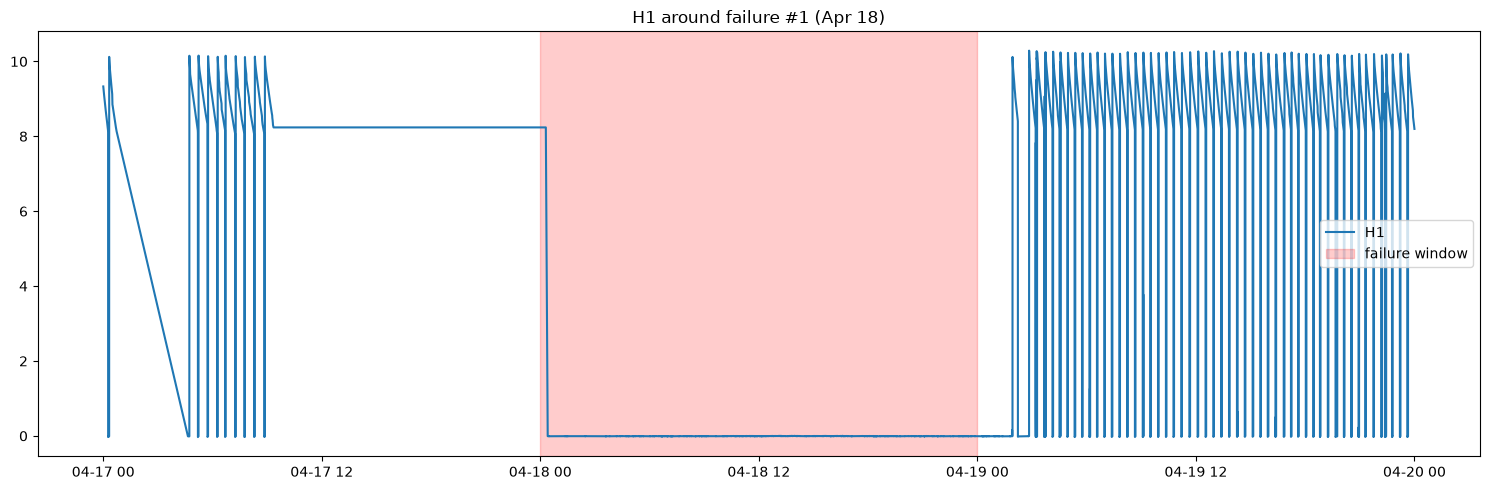

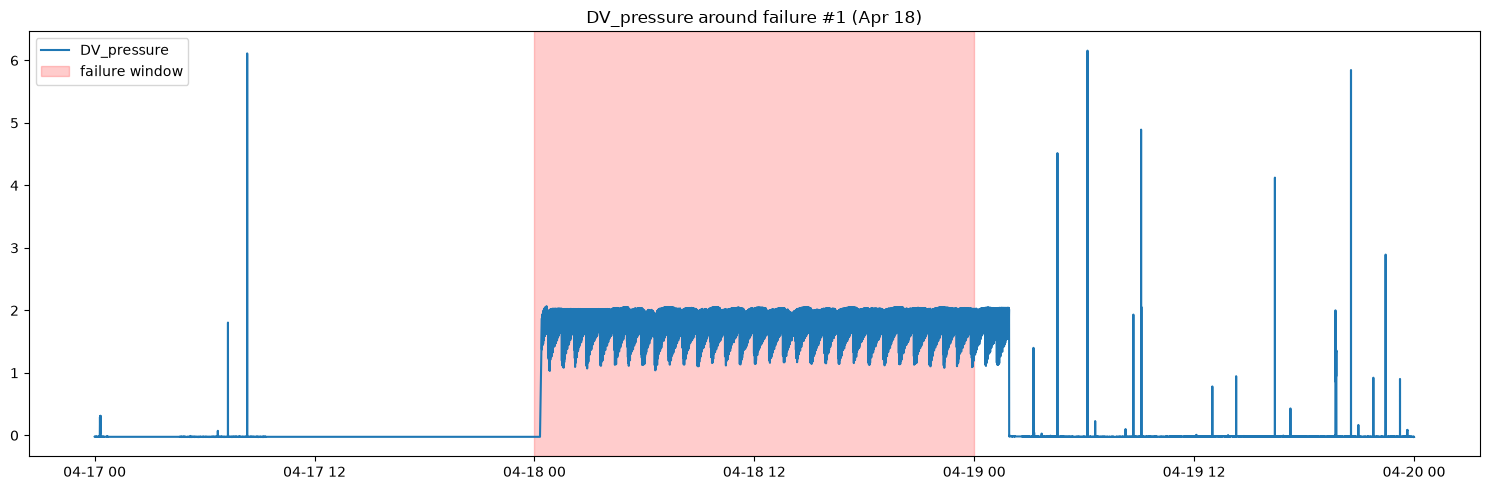

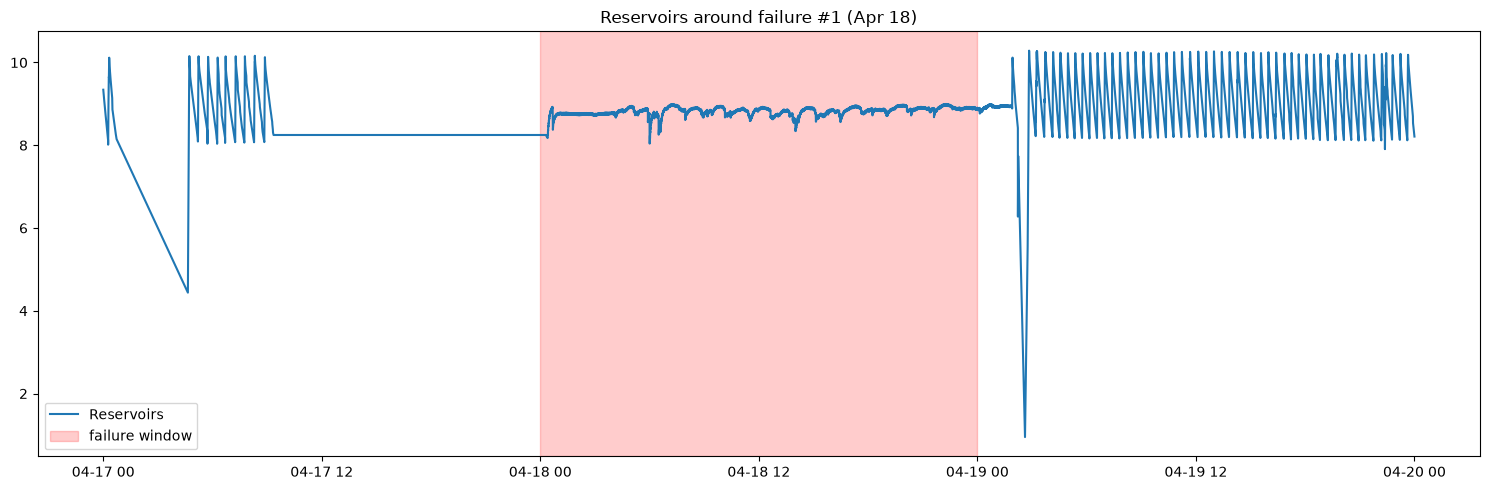

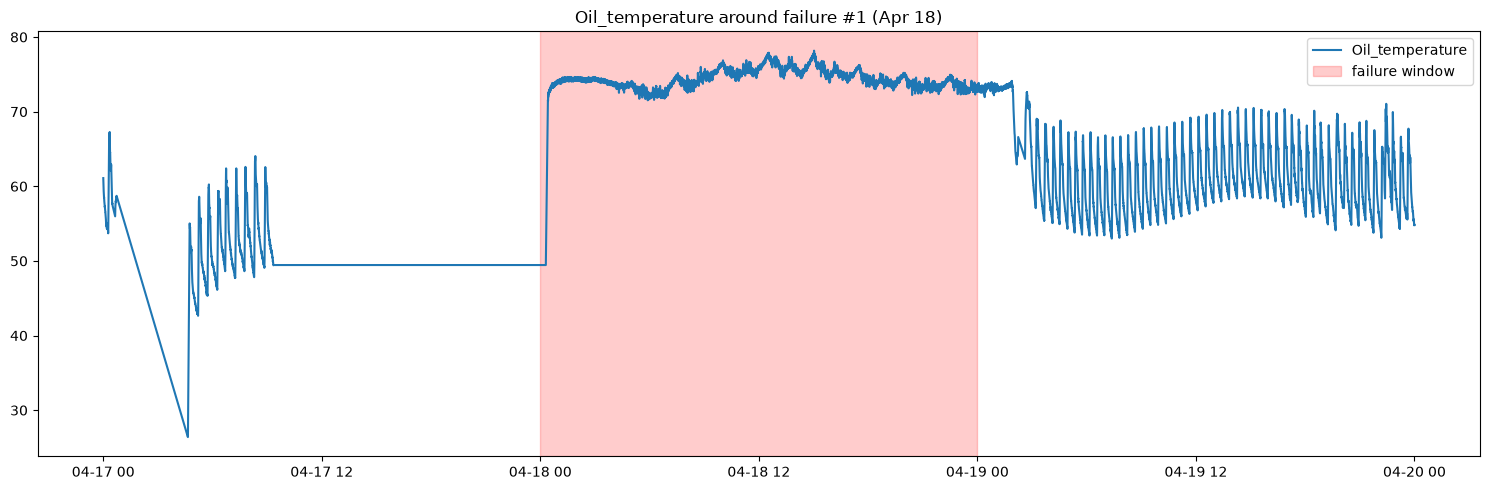

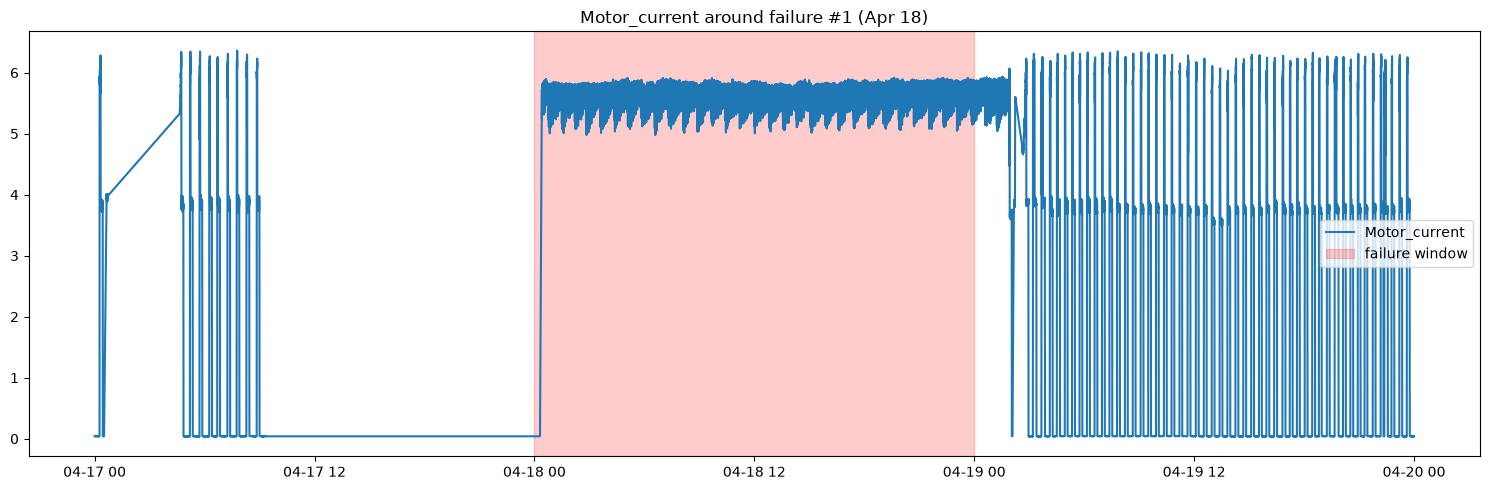

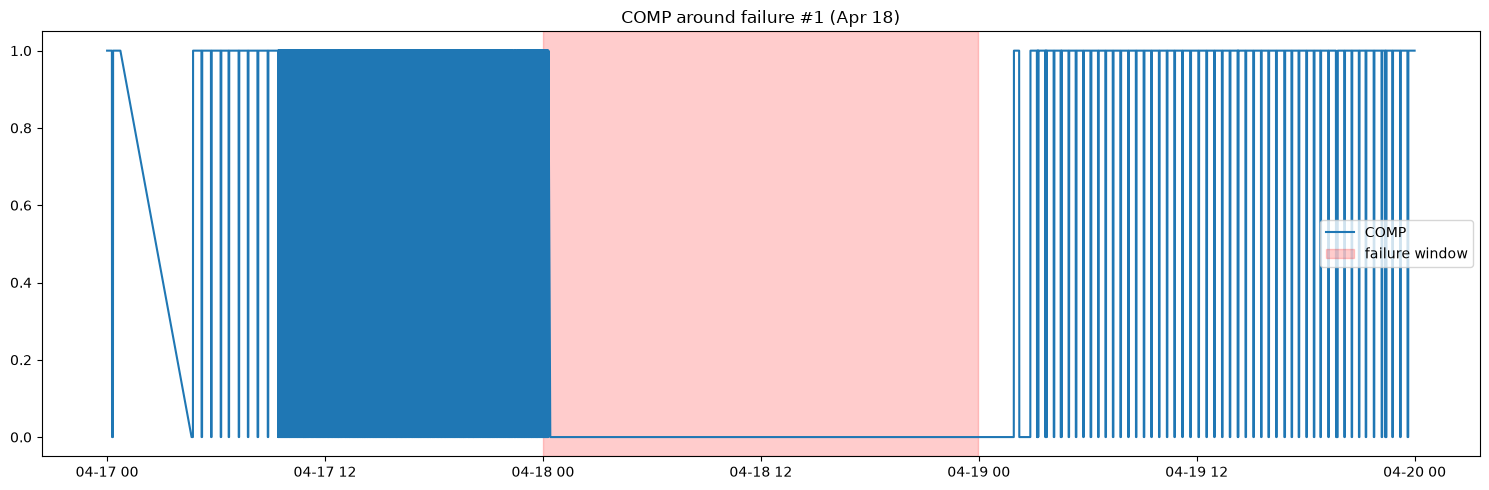

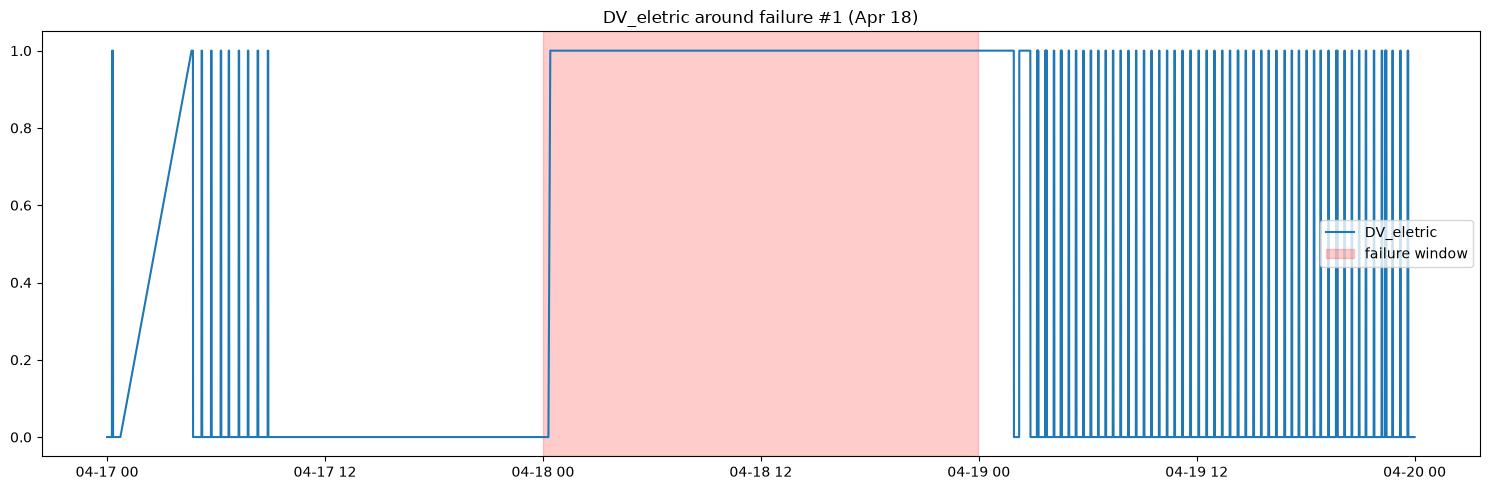

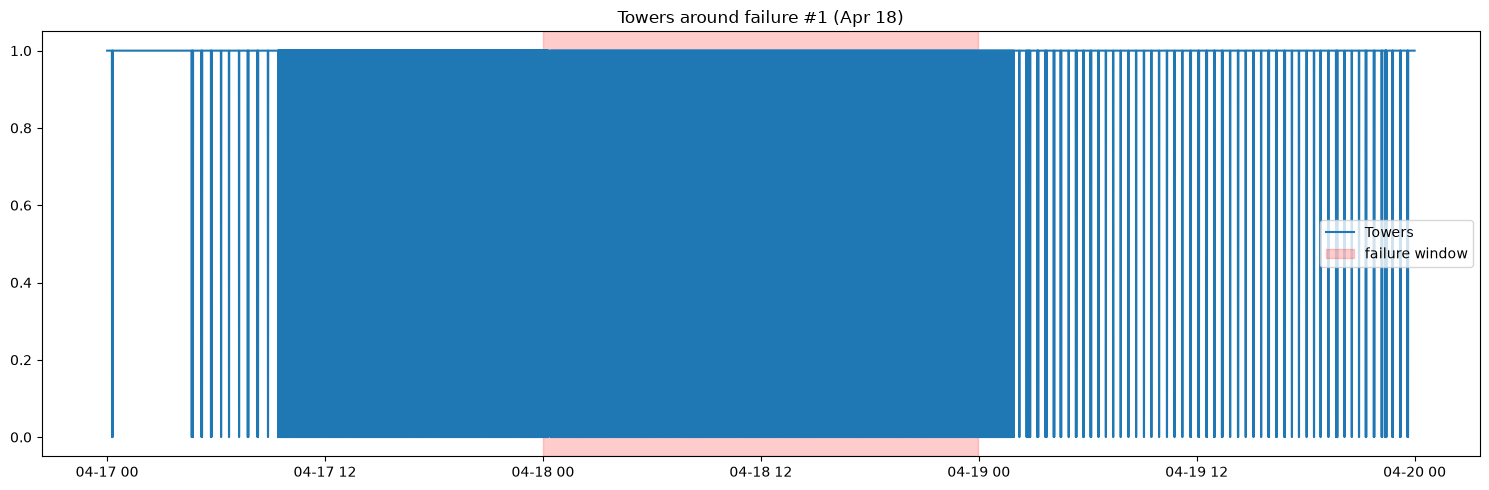

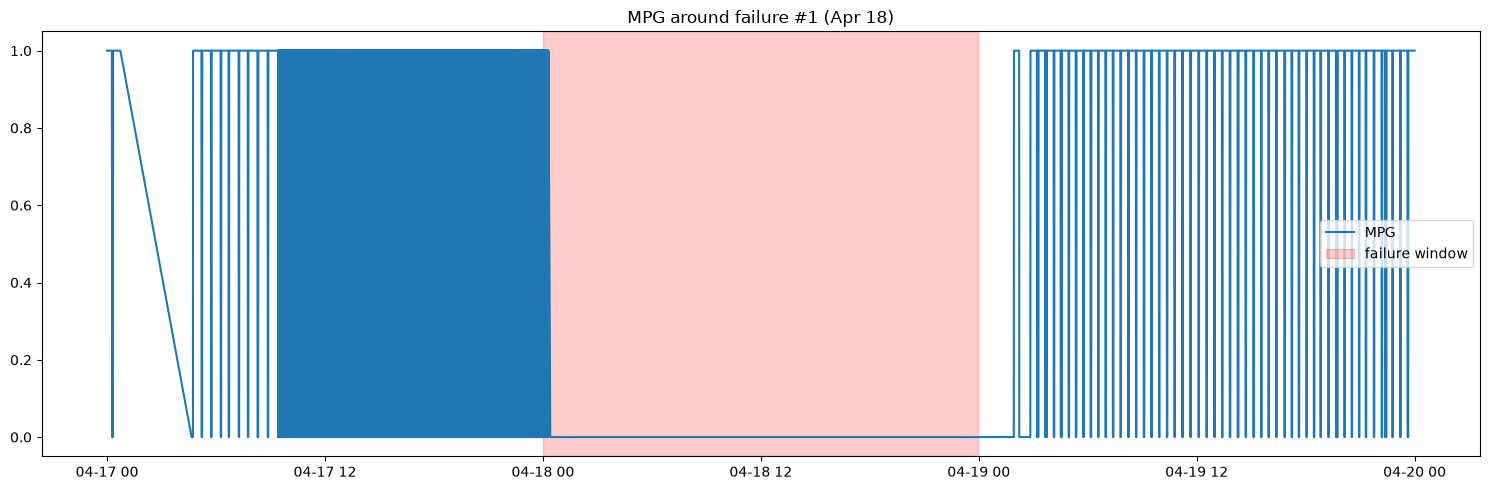

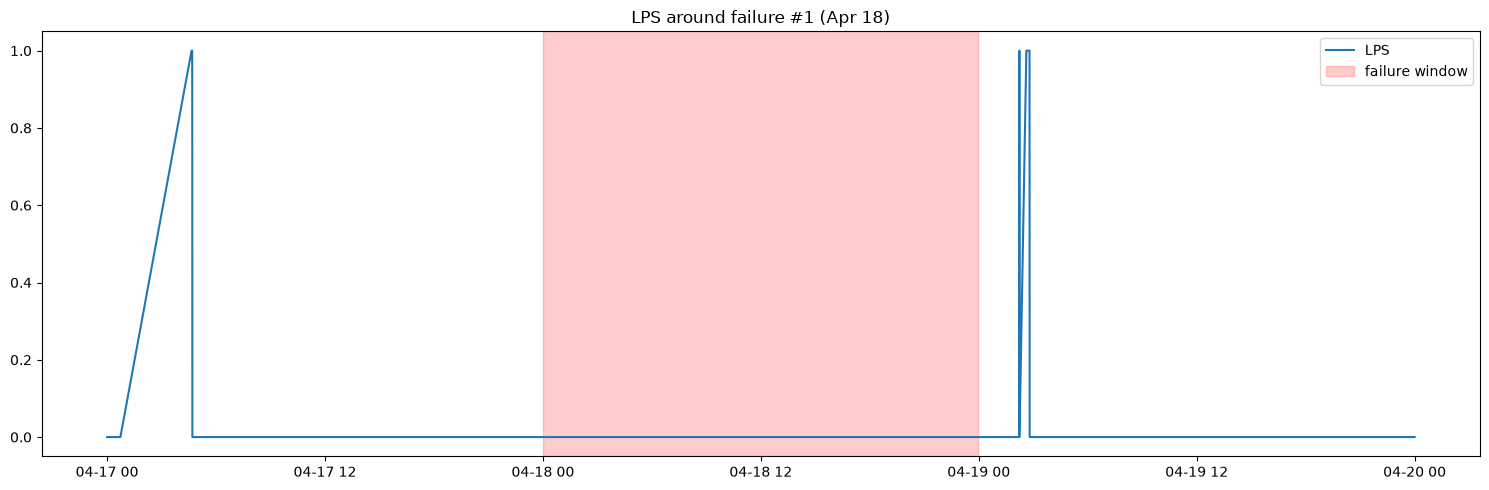

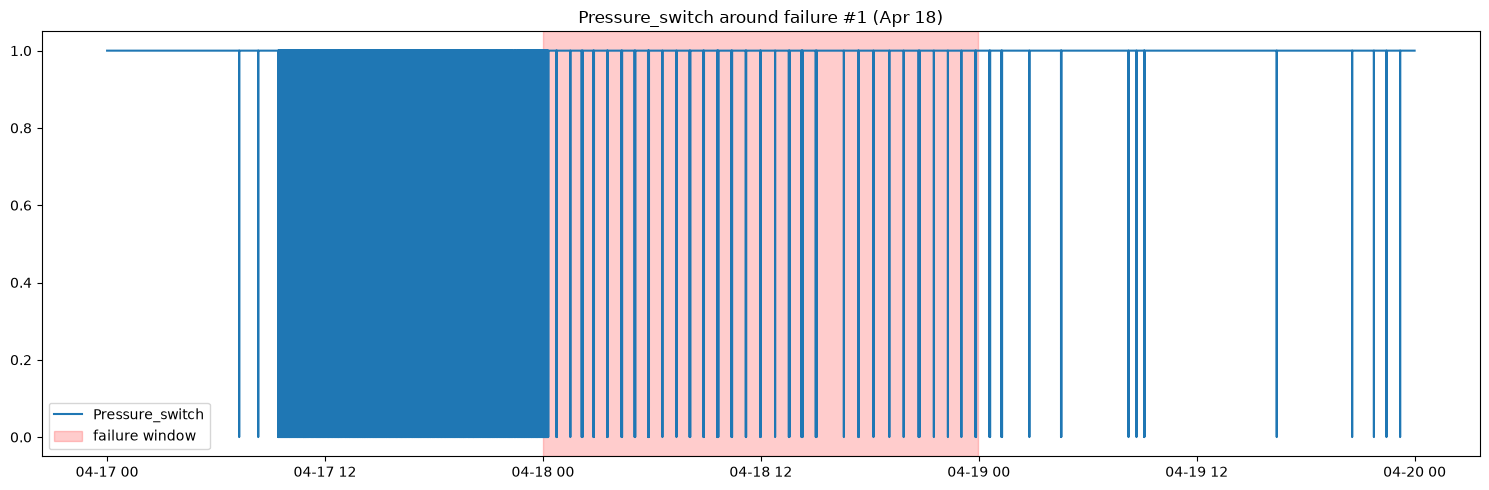

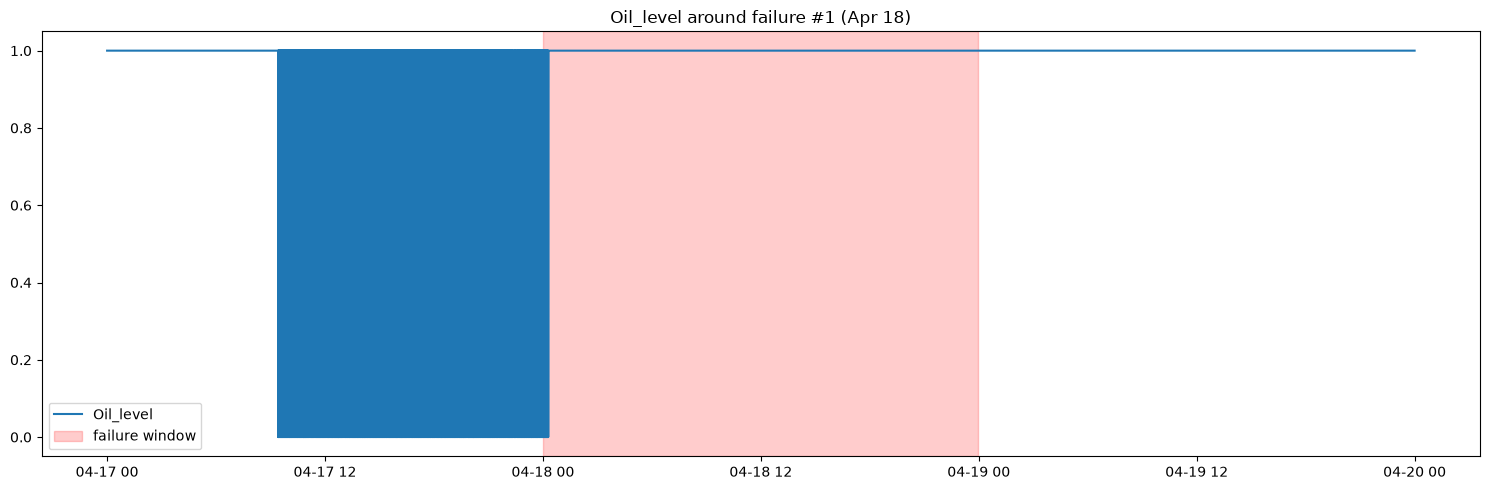

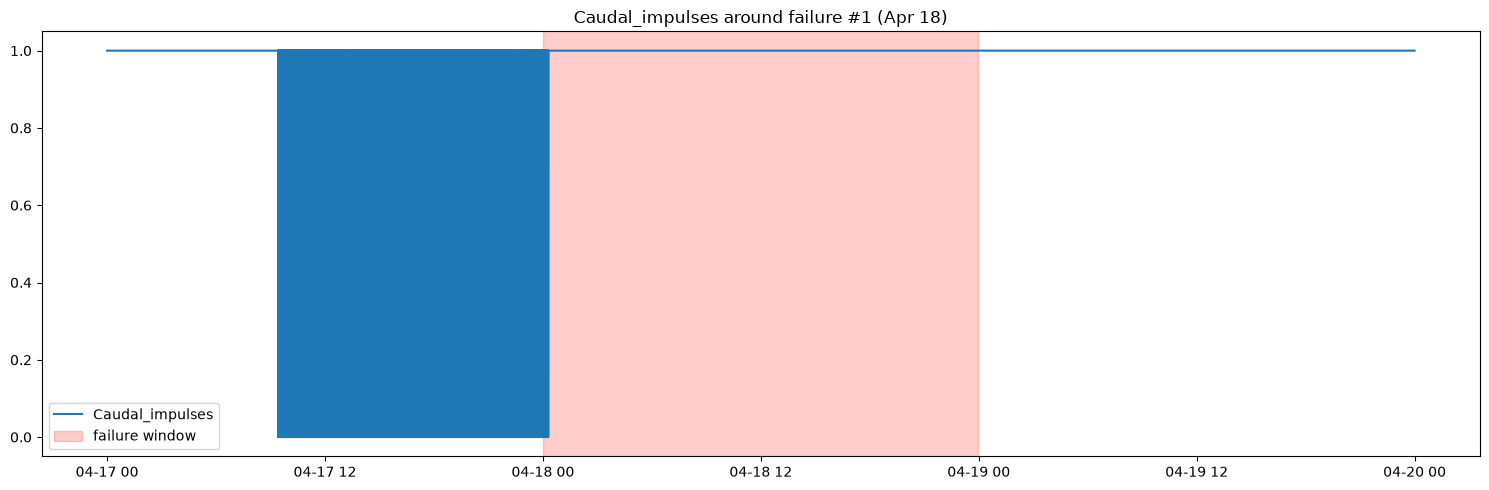

In [21]:
df_temp = df_temp = df.loc['2020-04-17':'2020-04-19']  

failure_start = pd.Timestamp('2020-04-18 00:00:00')
failure_end = pd.Timestamp('2020-04-18 23:59:00')

for col in df_temp.columns:
    if col != 'timestamp':
        plt.figure(figsize=(15, 5))
        plt.plot(df_temp.index, df_temp[col], label=col)
        plt.axvspan(failure_start, failure_end, color='red', alpha=0.2, label='failure window')
        plt.title(f'{col} around failure #1 (Apr 18)')
        plt.legend()
        plt.tight_layout()
        plt.show()

### 4. Principal Component Analysis

In [22]:
in_failure = pd.Series(False, index=df_resampled.index)
for _, fail in df_failures.iterrows():
    in_failure |= (df_resampled.index >= fail['start_time']) & (df_resampled.index <= fail['end_time'])

df_for_pca = df_resampled[~in_failure]

In [67]:
window = pd.Timedelta(hours=1)

feature_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

rolling_features = pd.DataFrame(index=df_for_pca.index)

for col in feature_cols:
    rolling_features[f'{col}_mean'] = df_for_pca[col].rolling(window, min_periods=60).mean()
    rolling_features[f'{col}_std'] = df_for_pca[col].rolling(window, min_periods=60).std()

for col in digital_cols:
    rolling_features[f'{col}_activity'] = df_for_pca[col].rolling(window, min_periods=60).mean()

rolling_features = rolling_features.dropna()

In [68]:
window = pd.Timedelta(hours=1)

feature_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

rolling_features_all = pd.DataFrame(index=df_resampled.index)

for col in feature_cols:
    rolling_features_all[f'{col}_mean'] = df_resampled[col].rolling(window, min_periods=60).mean()
    rolling_features_all[f'{col}_std'] = df_resampled[col].rolling(window, min_periods=60).std()

for col in digital_cols:
    rolling_features_all[f'{col}_activity'] = df_resampled[col].rolling(window, min_periods=60).mean()

rolling_features_all = rolling_features_all.dropna()

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipe = Pipeline([('scaler', StandardScaler()), ('reducer', PCA(n_components=0.9))])


In [70]:
pipe.fit(rolling_features) # fit only on normal data

print(len(pipe['reducer'].components_))

7


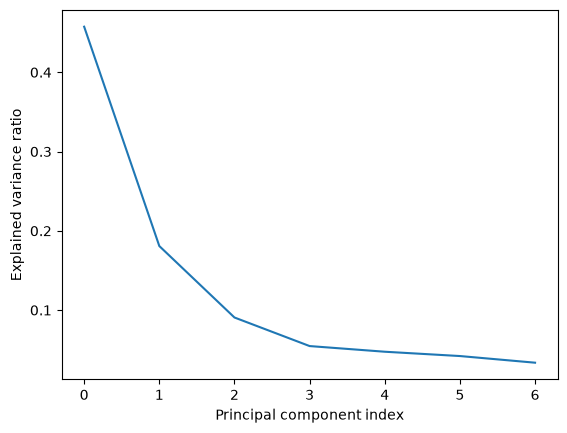

In [71]:
# Optimal number of components to explain 90% of the variance 
var = pipe['reducer'].explained_variance_ratio_
plt.plot(var)
plt.xlabel('Principal component index')
plt.ylabel('Explained variance ratio')
plt.show()


# Ref : https://scikit-learn.org/stable/common_pitfalls.html 
 "Common Pitfalls and Recommended Practices," explicitly names PCA as one of the transformations vulnerable to data leakage, alongside StandardScaler. Their stated rule: "it is important that these transformations are only learnt from the training data," achieved by using fit_transform on the training subset and transform (not fit) on everything else

 Sources:

- scikit-learn: Common Pitfalls and Recommended Practices
- On the Use of PCA for Diagnostics via Novelty Detection (PHM Society)
- Feature extraction for novelty detection as applied to fault detection in machinery (ScienceDirect)

In [72]:
# Version for scoring later: gaps out, failures still in
transformed_all = pipe.transform(rolling_features_all)

# Also keep the transformed "normal-only" version — you'll need this next,
# to fit Isolation Forest only on normal behavior
transformed_normal = pipe.transform(rolling_features)

In [73]:
#loadings = pd.DataFrame(pipe['reducer'].components_, columns=df_pca.columns, index=[f'PC{i+1}' for i in range(7)])
#print(loadings)

# Do later:  project your four known failure windows onto PC1 and PC2 specifically, and see whether they score visibly differently from normal operation — this is the direct, systematic answer to your very first question (finding failure similarity without eyeballing plots).

### 5. Predict Failures - Isolation Forest

In [74]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
iso_forest.fit(transformed_normal)

# Score everything, including the failure periods
anomaly_labels = iso_forest.predict(transformed_all)       # -1 = anomaly, 1 = normal
anomaly_scores = iso_forest.decision_function(transformed_all)  # continuous score; lower = more anomalous

In [75]:
rolling_features_all['anomaly_label'] = anomaly_labels
rolling_features_all['anomaly_score'] = anomaly_scores

In [76]:
print(len(rolling_features_all[rolling_features_all['anomaly_label'] == -1]))
print(len(rolling_features_all))

31670
237743


In [77]:
is_anom = rolling_features_all['anomaly_label'] == -1
anom_groups = (is_anom != is_anom.shift()).cumsum()

episodes = rolling_features_all[is_anom].groupby(anom_groups[is_anom]).apply(
    lambda g: pd.Series({'start': g.index.min(), 'end': g.index.max(), 'duration_rows': len(g)})
)
episodes = episodes.sort_values('duration_rows', ascending=False)
print(len(episodes))
episodes.head(15)

738


,start,end,duration_rows
anomaly_label,,,
870,2020-06-22 15:28:00,2020-06-25 05:08:00,3701
858,2020-06-05 09:51:00,2020-06-08 14:48:00,2785
846,2020-05-26 09:42:00,2020-05-28 03:16:00,2427
738,2020-04-17 09:47:00,2020-04-19 03:44:00,2366
832,2020-05-19 22:23:00,2020-05-21 06:57:00,1290
686,2020-03-28 07:24:00,2020-03-29 19:49:00,1272
744,2020-04-20 05:13:00,2020-04-21 01:16:00,1204
862,2020-06-12 02:30:00,2020-06-12 17:06:00,877
646,2020-03-12 00:24:00,2020-03-12 13:09:00,766


#### Quantify recall and precision against `df_failures` (instead of eyeballing)

For each anomaly episode, check whether it overlaps a documented failure window. From that: **recall** = how many of the 4 documented failures are caught by at least one episode; **precision** = of the anomaly episodes (and of the anomalous minutes), how many actually correspond to a documented failure vs. flag something else.

In [ ]:
def find_matching_failure(start, end, df_failures):
    for _, fail in df_failures.iterrows():
        if start <= fail['end_time'] and fail['start_time'] <= end:
            return fail['nr']
    return None

episodes['matched_failure'] = episodes.apply(
    lambda row: find_matching_failure(row['start'], row['end'], df_failures), axis=1
)

episodes[episodes['matched_failure'].notnull()]

In [ ]:
# Recall: how many documented failures are caught by at least one anomaly episode
matched_failures = sorted(episodes['matched_failure'].dropna().unique())
missed_failures = sorted(set(df_failures['nr']) - set(matched_failures))
print(f"Recall: {len(matched_failures)}/{len(df_failures)} documented failures matched -> "
      f"{len(matched_failures)/len(df_failures):.0%}")
print("Matched:", matched_failures)
print("Missed:", missed_failures)
print()

# Precision (episode-level): of all anomaly episodes, how many overlap a documented failure
n_matched_episodes = episodes['matched_failure'].notnull().sum()
n_total_episodes = len(episodes)
print(f"Episode-level precision: {n_matched_episodes}/{n_total_episodes} anomaly episodes "
      f"overlap a documented failure -> {n_matched_episodes/n_total_episodes:.1%}")

# Precision (time-level): of all anomalous minutes, how many fall inside a documented failure window
anomalous_rows = rolling_features_all[rolling_features_all['anomaly_label'] == -1]
in_doc_failure = pd.Series(False, index=anomalous_rows.index)
for _, fail in df_failures.iterrows():
    in_doc_failure |= (anomalous_rows.index >= fail['start_time']) & (anomalous_rows.index <= fail['end_time'])

n_tp_minutes = in_doc_failure.sum()
n_total_anom_minutes = len(anomalous_rows)
print(f"Time-level precision: {n_tp_minutes}/{n_total_anom_minutes} anomalous minutes fall inside "
      f"a documented failure window -> {n_tp_minutes/n_total_anom_minutes:.1%}")

4 for 4 recall, with the new feature set. That's a real improvement worth noting.

One thing needs direct follow-up before trusting this fully: Row 640, the single longest episode (Jun 22–25, 62.5 hours), is the exact same period we already investigated and found strong evidence was a data gap, not a real event — every sensor sat perfectly flat when we plotted it. If it's showing up again here, that's concerning: either there's a partial/degraded logging issue in that window that slipped past the NaN-based gap filter (a sparse trickle of real readings rather than a clean gap), or something else is going on. This needs to be checked directly, not assumed.

In [78]:
# filter rolling_features_all for 2020-06-22 15:21:00	2020-06-25 05:53:00

rolling_features_all_filtered = rolling_features_all.loc['2020-06-22 15:21:00':'2020-06-25 05:53:00']
rolling_features_all_filtered.head()  


,TP2_mean,TP2_std,TP3_mean,TP3_std,H1_mean,H1_std,DV_pressure_mean,DV_pressure_std,Reservoirs_mean,Reservoirs_std,...,COMP_activity,DV_eletric_activity,Towers_activity,MPG_activity,LPS_activity,Pressure_switch_activity,Oil_level_activity,Caudal_impulses_activity,anomaly_label,anomaly_score
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-06-22 15:21:00,3.071734,4.039167,8.927007,0.567824,5.777010,4.251833,-0.001037,0.099042,8.927560,0.566667,...,0.636111,0.320556,0.903889,0.636111,0.0,0.951111,0.956667,0.956667,1,0.034268
2020-06-22 15:22:00,3.211729,4.075953,8.919985,0.570419,5.628226,4.296195,-0.001048,0.099043,8.920476,0.569273,...,0.619444,0.333889,0.900556,0.619444,0.0,0.947778,0.953333,0.953333,1,0.031055
2020-06-22 15:23:00,3.351717,4.107566,8.914363,0.572845,5.480826,4.336014,-0.001075,0.099046,8.914810,0.571714,...,0.602778,0.347222,0.897222,0.602778,0.0,0.944444,0.950000,0.950000,1,0.025287
2020-06-22 15:24:00,3.491729,4.134100,8.910302,0.574892,5.334987,4.371671,-0.001081,0.099047,8.910698,0.573783,...,0.586111,0.363889,0.897222,0.586111,0.0,0.944444,0.950000,0.950000,1,0.023092
2020-06-22 15:25:00,3.631734,4.155675,8.907785,0.576348,5.190687,4.403372,-0.001098,0.099049,8.908121,0.575271,...,0.569444,0.377222,0.893889,0.569444,0.0,0.941111,0.946667,0.946667,1,0.017192


In [79]:

# filter df_resampled for 2020-06-22 15:21:00	2020-06-25 05:53:00

df_resampled_filtered = df_resampled.loc['2020-06-22 15:21:00':'2020-06-25 05:53:00']
df_resampled_filtered.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,,
2020-06-22 15:21:00,2020-06-22 15:21:00,8.39,8.506,-0.014,-0.014,8.506,65.15,5.575,0.0,0.6,0.6,0.0,0.0,0.6,0.6,0.6
2020-06-22 15:22:00,2020-06-22 15:22:00,8.39,8.506,-0.014,-0.014,8.506,65.15,5.575,0.0,0.8,0.8,0.0,0.0,0.8,0.8,0.8
2020-06-22 15:23:00,2020-06-22 15:23:00,8.39,8.506,-0.014,-0.014,8.506,65.15,5.575,0.0,0.8,0.8,0.0,0.0,0.8,0.8,0.8
2020-06-22 15:24:00,2020-06-22 15:24:00,8.39,8.506,-0.014,-0.014,8.506,65.15,5.575,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
2020-06-22 15:25:00,2020-06-22 15:25:00,8.39,8.506,-0.014,-0.014,8.506,65.15,5.575,0.0,0.8,0.8,0.0,0.0,0.8,0.8,0.8


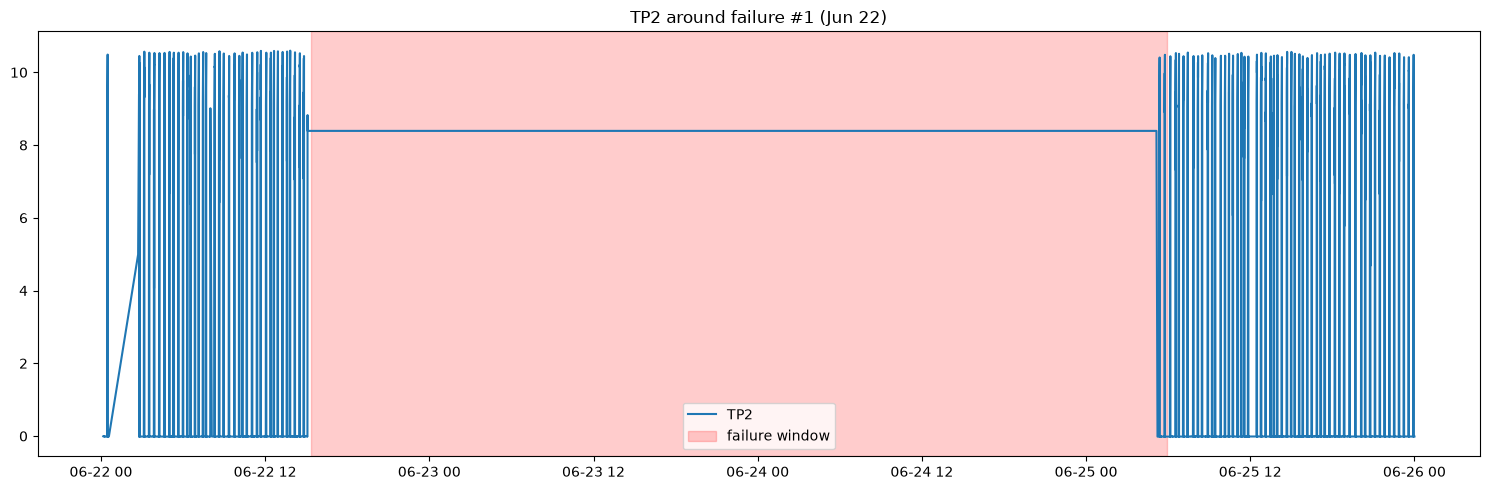

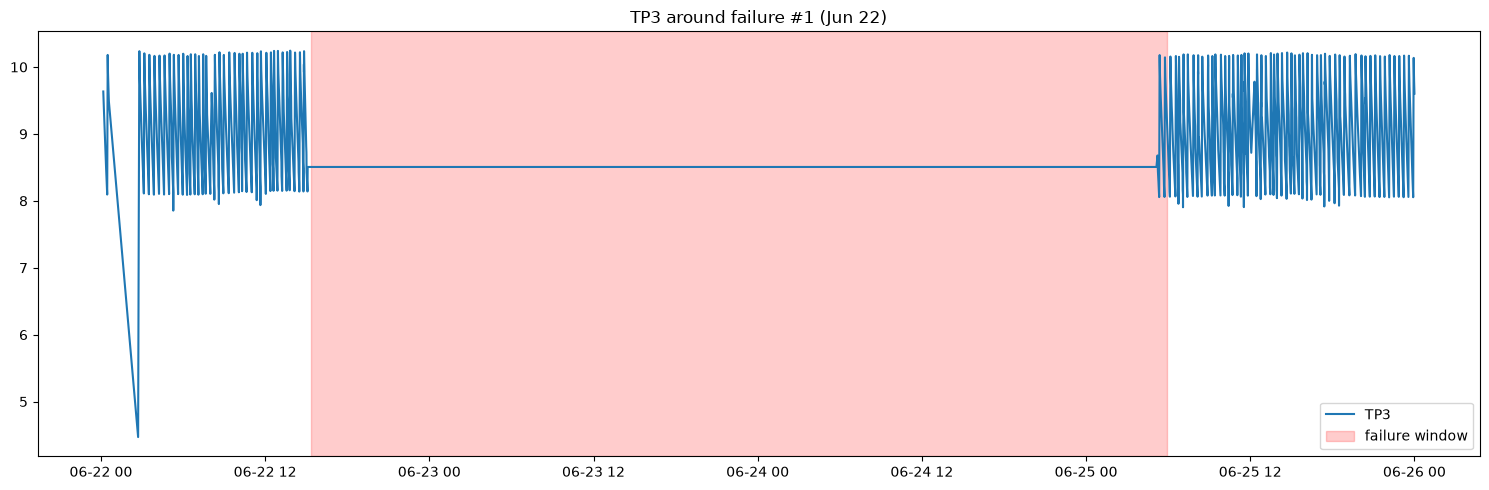

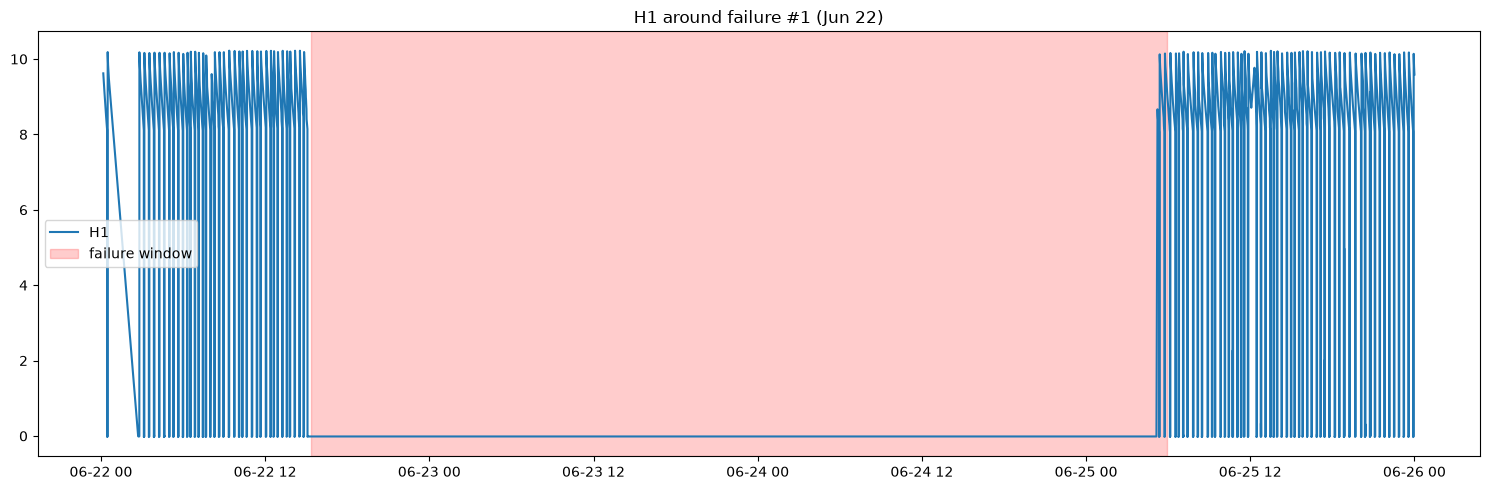

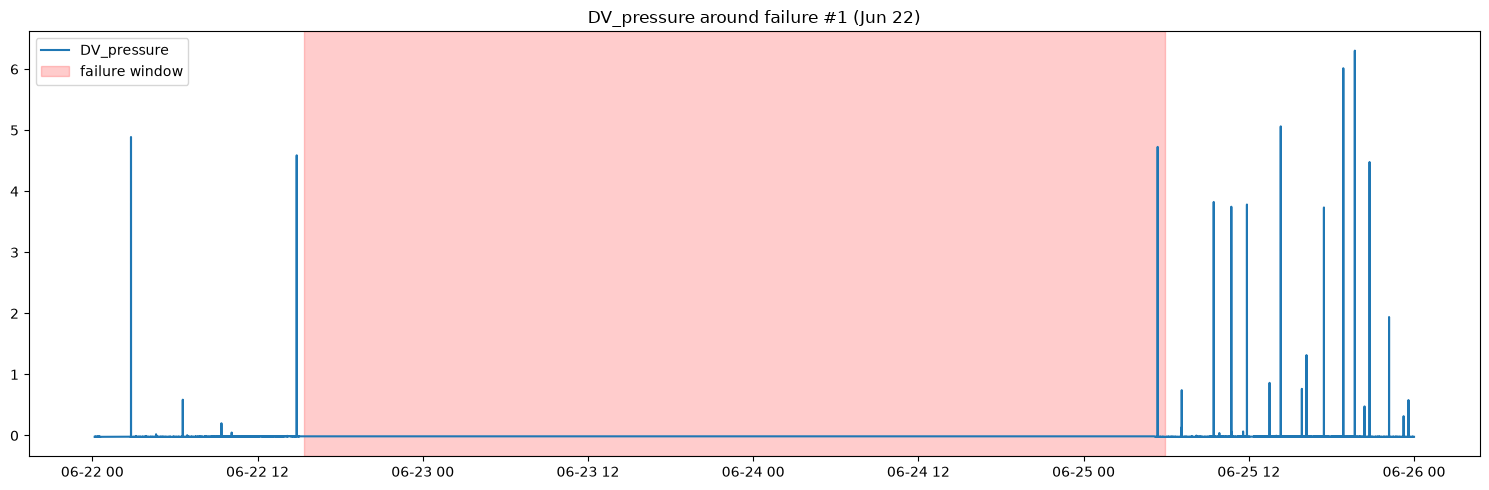

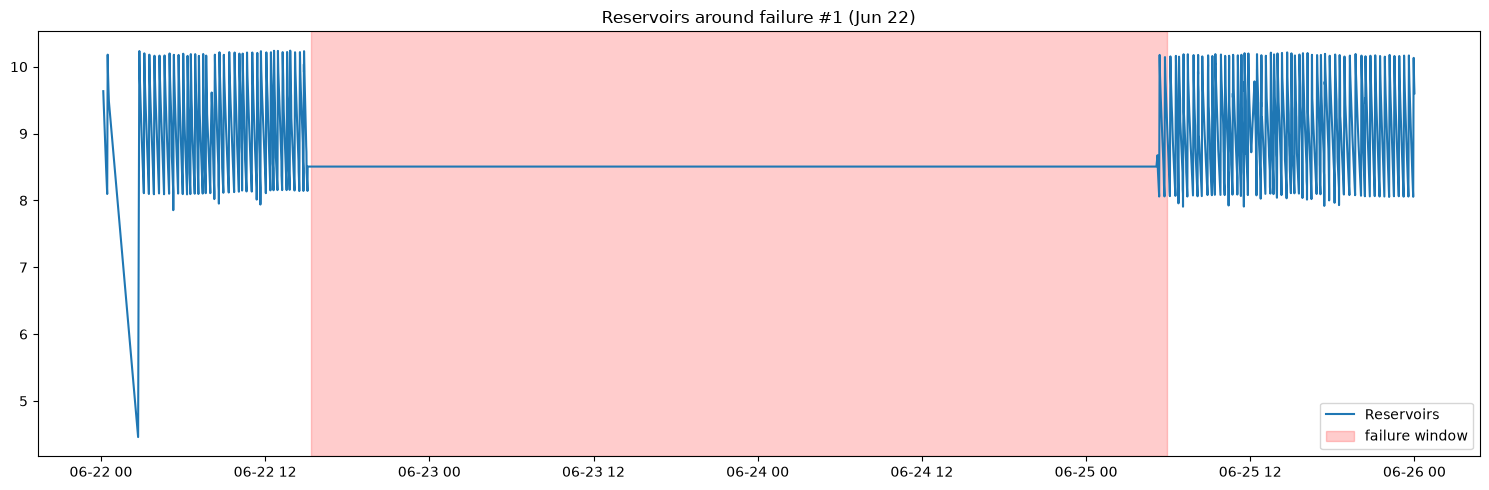

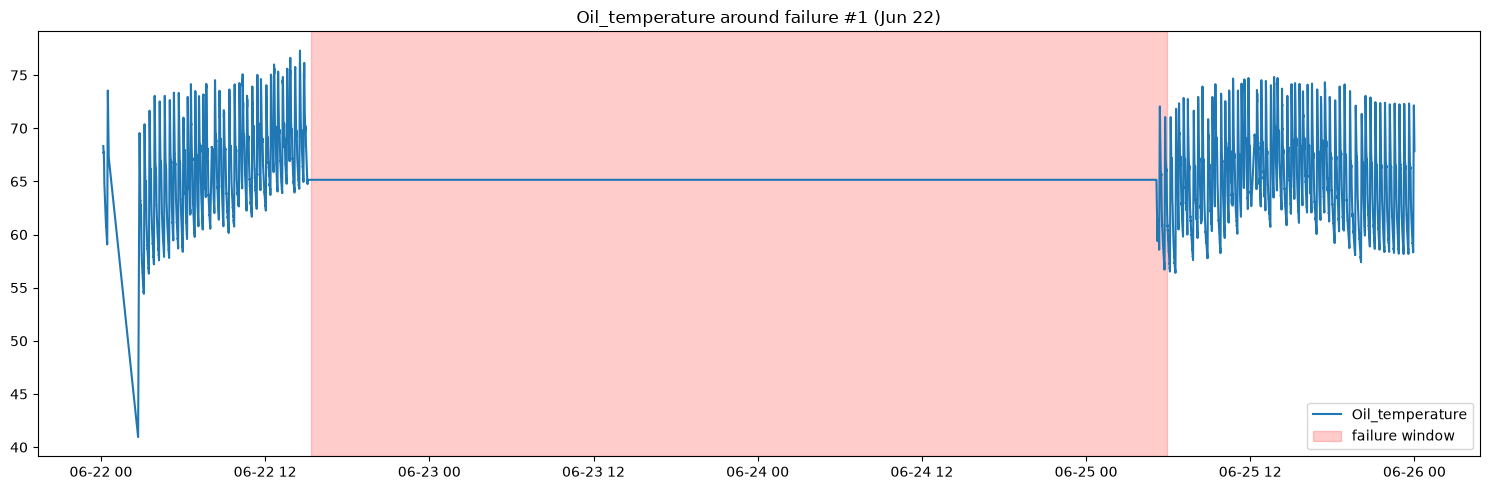

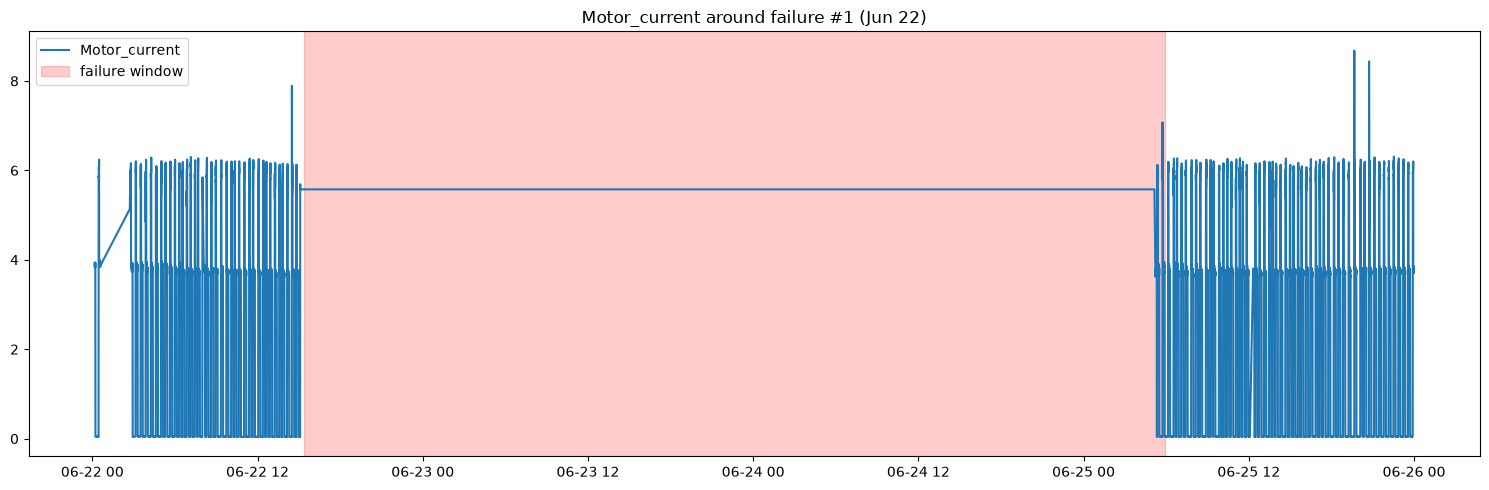

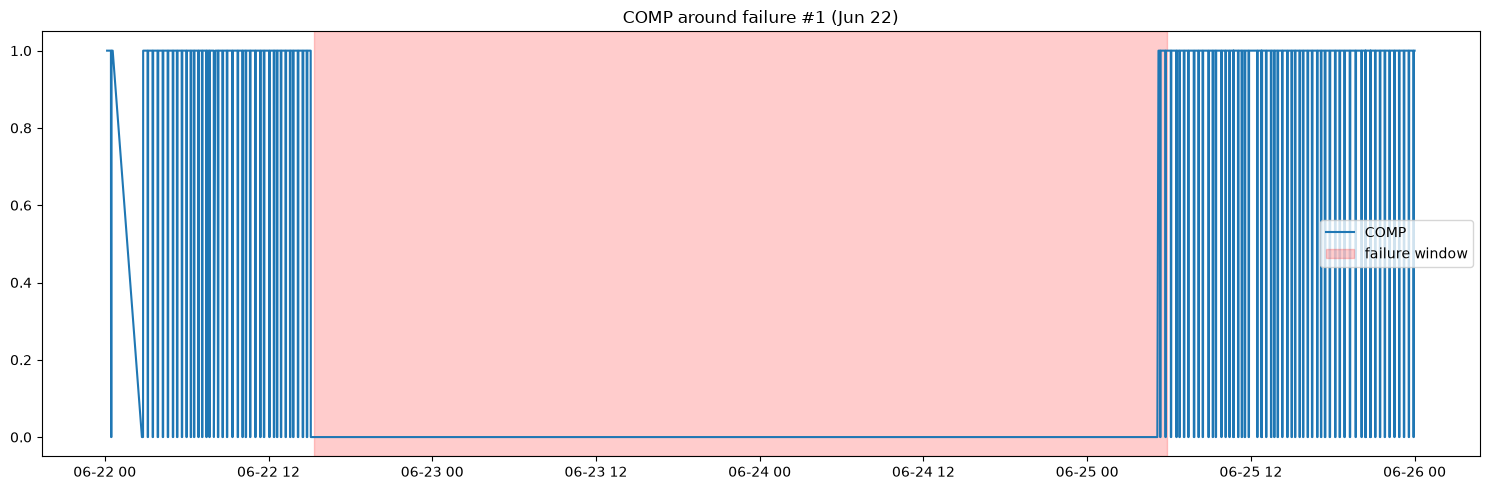

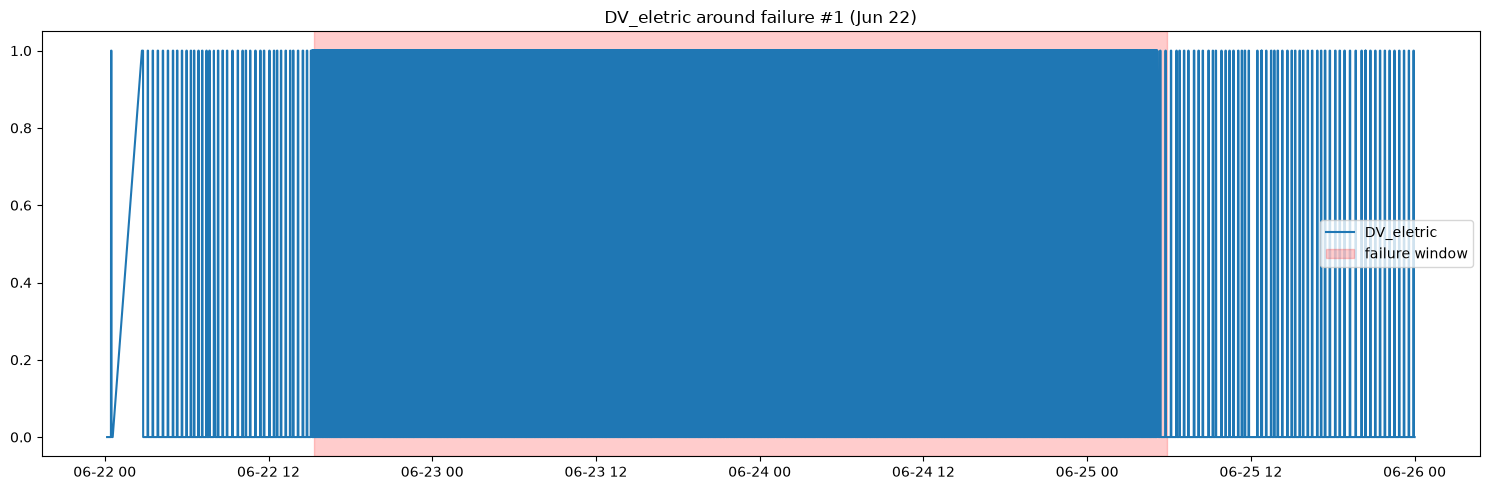

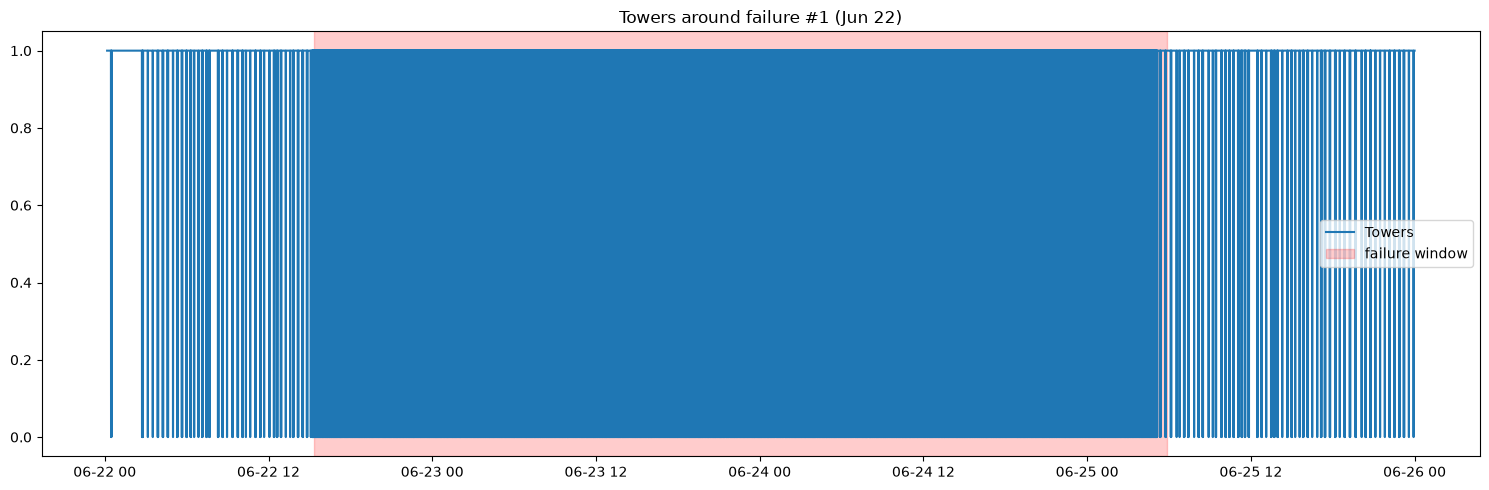

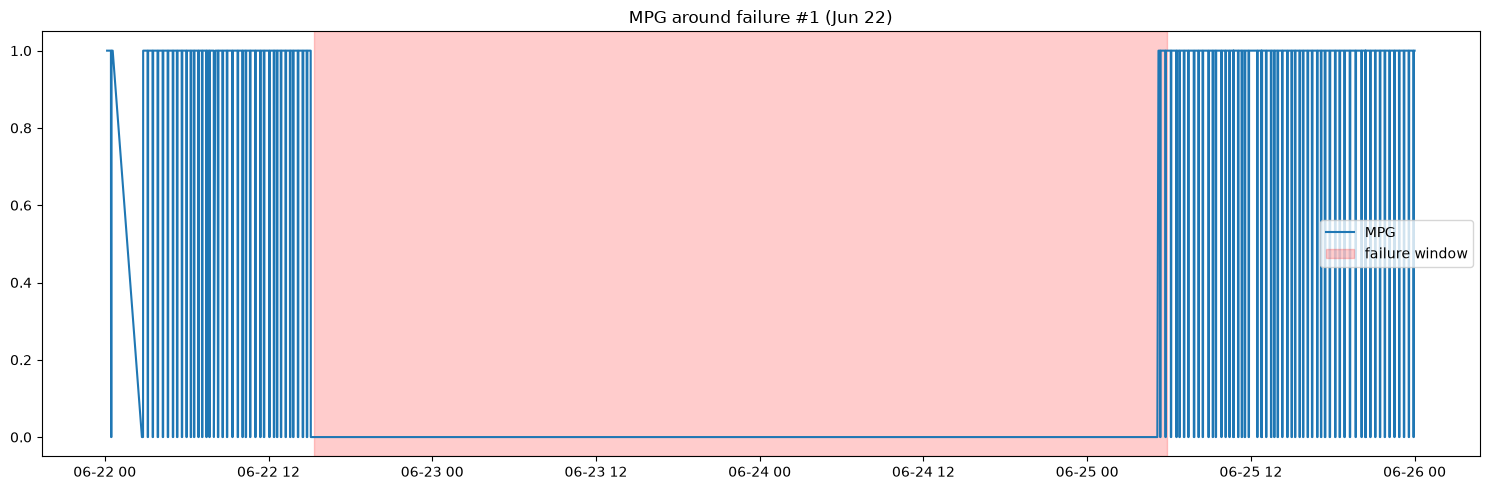

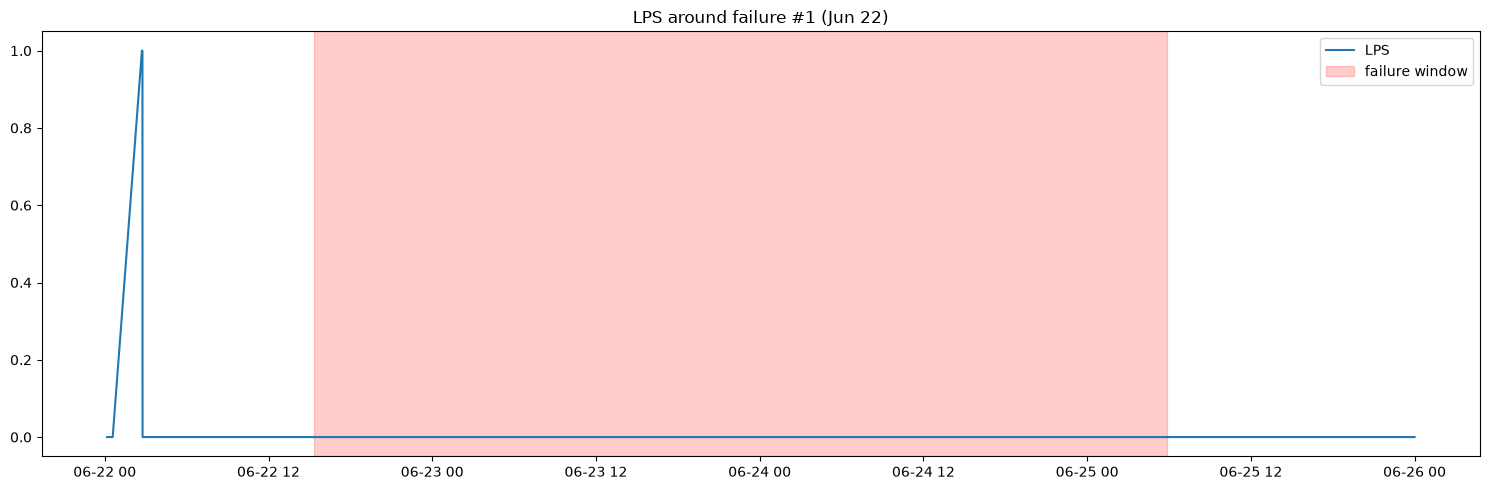

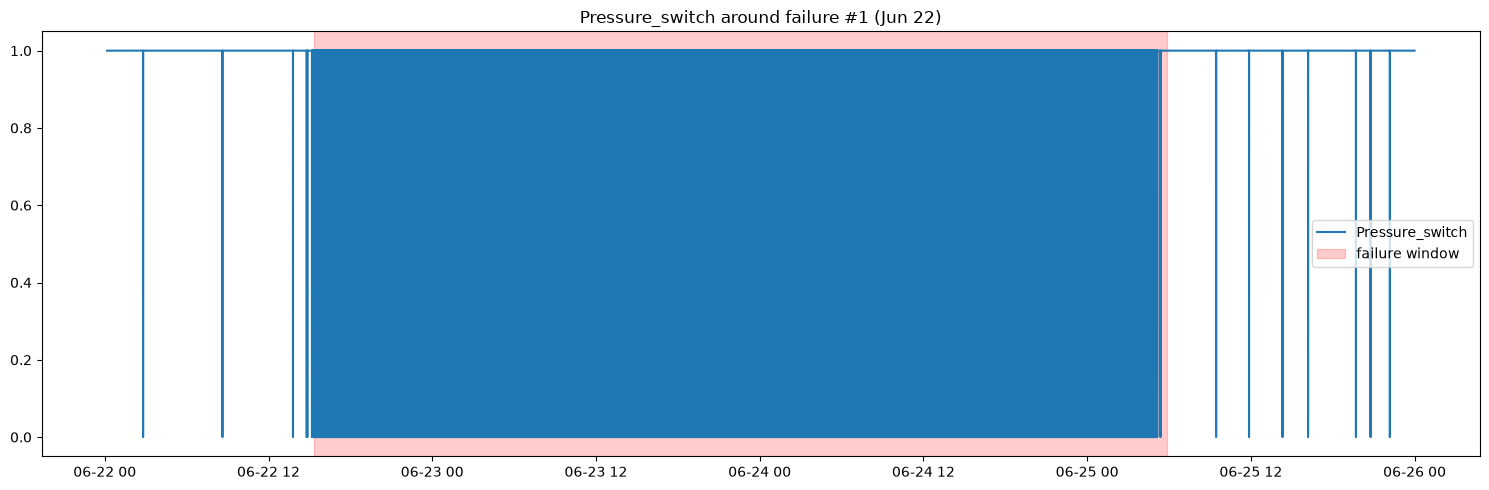

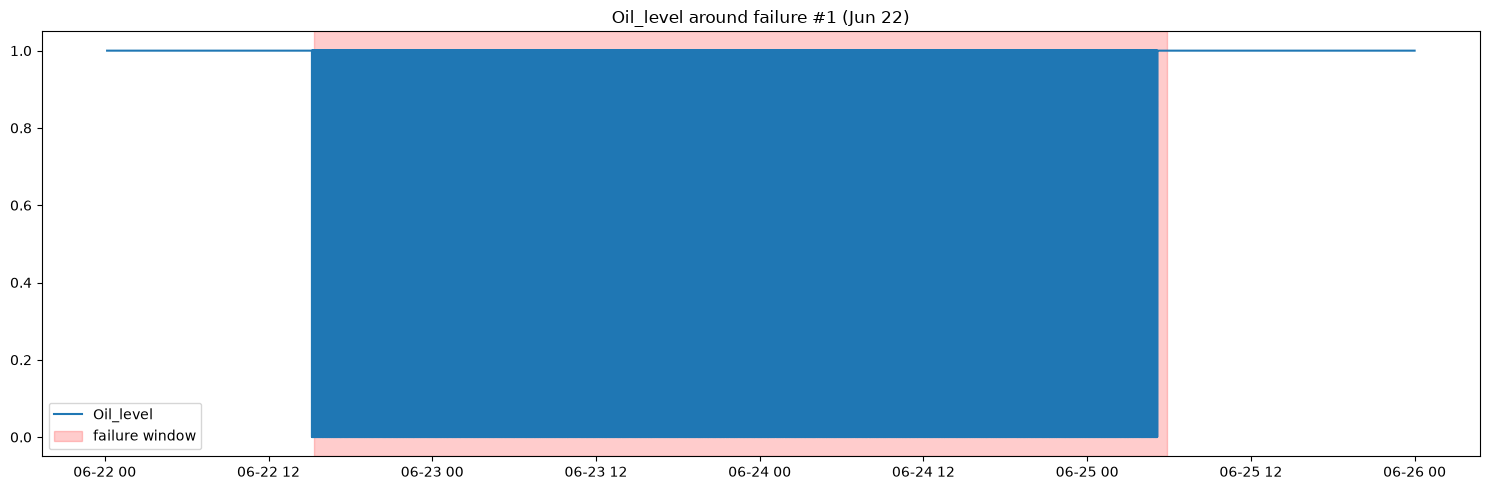

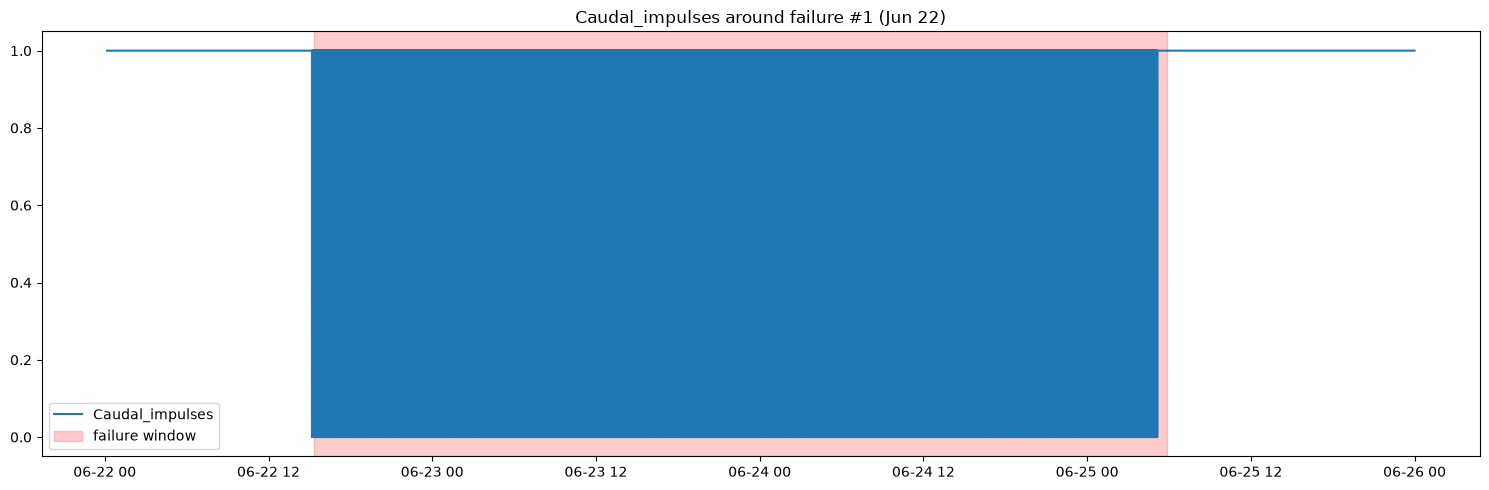

In [80]:
df_temp = df.loc['2020-06-22':'2020-06-25']

failure_start = pd.Timestamp('2020-06-22 15:21:00')
failure_end = pd.Timestamp('2020-06-25 05:53:00')

for col in df_temp.columns:
    if col != 'timestamp':
        plt.figure(figsize=(15, 5))
        plt.plot(df_temp.index, df_temp[col], label=col)
        plt.axvspan(failure_start, failure_end, color='red', alpha=0.2, label='failure window')
        plt.title(f'{col} around failure #1 (Jun 22)')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [81]:
#Dynamic Time Warping (DTW) 

In [82]:
# Sparse Autoencoder trained only on "normal" data
# A related, simpler approach:  4 known failures as templates, and scan the rest of the dataset with a sliding window, computing DTW distance (or feature-vector distance) from each window to the nearest known-failure template — windows that

In [83]:
# The failures typically are undetectable according to traditional maintenance criteria (predefined thresholds)." That's their own stated reason for building this as a machine-learning benchmark in the first place — simple threshold-crossing rules don't reliably catch these failures. So there isn't an industry-standard threshold you're missing that would make this easy; the difficulty you've been experiencing (needing behavioral/pattern-based features rather than simple value thresholds) is the actual documented nature of the problem, not a gap in your approach.

In [84]:
# three key open research lines for the PdM domain: failure prediction, remaining useful life (RUL), and root cause analyses (RCA).